In [6]:
import os, random, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt

# reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device     : {DEVICE}")
print(f"PyTorch    : {torch.__version__}")

Device     : cuda
PyTorch    : 2.10.0+cu128


In [12]:
import zipfile

zip_path   = "/content/archive(4).zip"
extract_to = "/content/brain_tumor"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)

print("Extraction done!")
for f in sorted(os.listdir(extract_to)):
    print(f"  {f}/")

Extraction done!
  Testing/
  Training/


In [13]:
# ── paths & data ─────────────────────────────────────────────
DATA_DIR         = "/content/brain_tumor"
NUM_CLASSES      = 4
IMG_SIZE         = 224
LABELED_FRAC     = 0.10

# ── training ─────────────────────────────────────────────────
BATCH_LABELED    = 16
BATCH_UNLABELED  = 32
EPOCHS           = 50
LR               = 1e-4

# ── FixMatch settings ────────────────────────────────────────
THRESHOLD        = 0.95

# ── Mean Teacher settings ────────────────────────────────────
EMA_DECAY        = 0.999
CONSISTENCY_W    = 1.0
RAMPUP_EPOCHS    = 5

print("Config ready!")
print(f"Labeled samples   : {int(5600 * LABELED_FRAC)} (10%)")
print(f"Unlabeled samples : {int(5600 * (1 - LABELED_FRAC))} (90%)")
print(f"Test samples      : 1600")
print(f"Threshold         : {THRESHOLD}")
print(f"EMA decay         : {EMA_DECAY}")

Config ready!
Labeled samples   : 560 (10%)
Unlabeled samples : 5040 (90%)
Test samples      : 1600
Threshold         : 0.95
EMA decay         : 0.999


In [14]:
# Weak augmentation → teacher sees this, generates stable pseudo-labels
weak_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Strong augmentation → student must classify correctly under heavy distortion
strong_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15),
                            scale=(0.85, 1.15)),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Validation — no augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

print("Augmentations ready!")

Augmentations ready!


In [15]:
class BrainTumorDataset(Dataset):
    def __init__(self, root, split="Training", transform=None):
        self.transform   = transform
        self.samples     = []
        self.class_names = sorted(os.listdir(os.path.join(root, split)))
        for idx, cls in enumerate(self.class_names):
            folder = os.path.join(root, split, cls)
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(folder, fname), idx))

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label


class UnlabeledDualViewDataset(Dataset):
    """Returns (weak_view, strong_view) for each unlabeled image."""
    def __init__(self, root, split="Training"):
        self.paths = []
        for cls in os.listdir(os.path.join(root, split)):
            folder = os.path.join(root, split, cls)
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.paths.append(os.path.join(folder, fname))

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return weak_transform(img), strong_transform(img)


# ── build split ───────────────────────────────────────────────
full_train = BrainTumorDataset(DATA_DIR, split="Training", transform=strong_transform)
all_idx    = list(range(len(full_train)))
all_labels = [full_train.samples[i][1] for i in all_idx]

labeled_idx, _ = train_test_split(
    all_idx, train_size=LABELED_FRAC,
    stratify=all_labels, random_state=SEED
)

labeled_dataset   = Subset(full_train, labeled_idx)
unlabeled_dataset = UnlabeledDualViewDataset(DATA_DIR, split="Training")
val_dataset       = BrainTumorDataset(DATA_DIR, split="Testing", transform=val_transform)

labeled_loader   = DataLoader(labeled_dataset,   batch_size=BATCH_LABELED,
                               shuffle=True,  drop_last=True,  num_workers=2, pin_memory=True)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=BATCH_UNLABELED,
                               shuffle=True,  drop_last=True,  num_workers=2, pin_memory=True)
val_loader       = DataLoader(val_dataset,       batch_size=32,
                               shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = full_train.class_names
print(f"Classes          : {CLASS_NAMES}")
print(f"Labeled samples  : {len(labeled_dataset)}")
print(f"Unlabeled samples: {len(unlabeled_dataset)}")
print(f"Test samples     : {len(val_dataset)}")

Classes          : ['glioma', 'meningioma', 'notumor', 'pituitary']
Labeled samples  : 560
Unlabeled samples: 5600
Test samples     : 1600


In [16]:
def build_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# student → trained via backprop
student = build_resnet50(NUM_CLASSES).to(DEVICE)

# teacher → updated only via EMA, never backprop
teacher = build_resnet50(NUM_CLASSES).to(DEVICE)
teacher.load_state_dict(student.state_dict())
for param in teacher.parameters():
    param.requires_grad = False

optimizer = optim.Adam(student.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def update_ema(student, teacher, decay):
    """Soft update: θ_teacher = decay * θ_teacher + (1 - decay) * θ_student"""
    with torch.no_grad():
        for t, s in zip(teacher.parameters(), student.parameters()):
            t.data.mul_(decay).add_(s.data * (1.0 - decay))

def consistency_weight(epoch):
    """Ramp up consistency weight over first RAMPUP_EPOCHS epochs."""
    if epoch >= RAMPUP_EPOCHS:
        return CONSISTENCY_W
    return CONSISTENCY_W * (epoch / RAMPUP_EPOCHS)

total_params = sum(p.numel() for p in student.parameters() if p.requires_grad)
print(f"Student params   : {total_params:,}")
print(f"Teacher params   : {sum(p.numel() for p in teacher.parameters()):,}")
print(f"Student on       : {next(student.parameters()).device}")
print(f"Teacher on       : {next(teacher.parameters()).device}")
print("Models ready!")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 144MB/s]


Student params   : 23,516,228
Teacher params   : 23,516,228
Student on       : cuda:0
Teacher on       : cuda:0
Models ready!


In [ ]:
def train_one_epoch(student, teacher, labeled_loader, unlabeled_loader,
                    optimizer, epoch):
    student.train()
    teacher.train()

    total_sup      = 0.0
    total_unsup    = 0.0
    total_cons     = 0.0
    total_masked   = 0
    total_unlab    = 0
    correct = 0; total = 0
    cons_w         = consistency_weight(epoch)
    unlabeled_iter = iter(unlabeled_loader)

    for imgs_l, labels in labeled_loader:
        imgs_l = imgs_l.to(DEVICE)
        labels = labels.to(DEVICE)

        try:
            imgs_weak, imgs_strong = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(unlabeled_loader)
            imgs_weak, imgs_strong = next(unlabeled_iter)

        imgs_weak   = imgs_weak.to(DEVICE)
        imgs_strong = imgs_strong.to(DEVICE)

        # ── supervised loss (student on labeled) 
        logits_l = student(imgs_l)
        sup_loss = F.cross_entropy(logits_l, labels)

        # ── teacher predictions on weak view (no grad) 
        # Mean Teacher contribution: teacher generates pseudo-labels
        # Teacher is more stable than student due to EMA
        with torch.no_grad():
            teacher_logits_weak  = teacher(imgs_weak)
            teacher_probs        = torch.softmax(teacher_logits_weak, dim=1)
            pseudo_labels        = teacher_probs.argmax(dim=1)
            max_probs            = teacher_probs.max(dim=1).values

        # ── FixMatch contribution: threshold mask
        # Only accept pseudo-labels where teacher is confident
        mask = (max_probs >= THRESHOLD).float()

        # ── student predictions on strong view 
        student_logits_strong = student(imgs_strong)

        # ── FixMatch unsupervised loss 
        # Student must agree with teacher on strongly augmented view
        unsup_loss_per_sample = F.cross_entropy(
            student_logits_strong, pseudo_labels, reduction='none'
        )
        unsup_loss = (unsup_loss_per_sample * mask).mean()

        # ── Mean Teacher consistency loss 
        # Student soft predictions must match teacher soft predictions
        student_probs_strong  = torch.softmax(student_logits_strong, dim=1)
        cons_loss = F.mse_loss(student_probs_strong, teacher_probs)

        # ── total loss ────────────────────────────────────────
        loss = sup_loss + unsup_loss + cons_w * cons_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # ── EMA update teacher ────────────────────────────────
        update_ema(student, teacher, EMA_DECAY)

        # ── metrics ───────────────────────────────────────────
        total_sup    += sup_loss.item()
        total_unsup  += unsup_loss.item()
        total_cons   += cons_loss.item()
        total_masked += mask.sum().item()
        total_unlab  += mask.size(0)
        preds    = logits_l.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    n          = len(labeled_loader)
    mask_ratio = 100.0 * total_masked / max(total_unlab, 1)
    return (total_sup/n, total_unsup/n, total_cons/n,
            100.*correct/total, mask_ratio)


def evaluate(model, loader):
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return 100. * correct / total

print("Hybrid training functions ready!")

Hybrid training functions ready!


In [19]:
# ── fix settings ─────────────────────────────────────────────
THRESHOLD     = 0.80
EMA_DECAY     = 0.99
RAMPUP_EPOCHS = 10

# ── reset fresh models ────────────────────────────────────────
student = build_resnet50(NUM_CLASSES).to(DEVICE)
teacher = build_resnet50(NUM_CLASSES).to(DEVICE)
teacher.load_state_dict(student.state_dict())
for param in teacher.parameters():
    param.requires_grad = False

optimizer = optim.Adam(student.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── training loop ─────────────────────────────────────────────
best_acc = 0.0
history  = {
    "sup_loss": [], "unsup_loss": [], "cons_loss": [],
    "train_acc": [], "val_student": [], "val_teacher": [],
    "mask_ratio": []
}

print(f"{'Ep':>3} | {'SupLoss':>8} | {'UnsupLoss':>9} | {'ConsLoss':>9} | {'TrainAcc':>8} | {'Student':>7} | {'Teacher':>7} | {'Mask%':>6}")
print("-" * 85)

for epoch in range(1, EPOCHS + 1):
    sup_l, unsup_l, cons_l, train_acc, mask_ratio = train_one_epoch(
        student, teacher, labeled_loader, unlabeled_loader,
        optimizer, epoch
    )
    val_s = evaluate(student, val_loader)
    val_t = evaluate(teacher, val_loader)
    scheduler.step()

    history["sup_loss"].append(sup_l)
    history["unsup_loss"].append(unsup_l)
    history["cons_loss"].append(cons_l)
    history["train_acc"].append(train_acc)
    history["val_student"].append(val_s)
    history["val_teacher"].append(val_t)
    history["mask_ratio"].append(mask_ratio)

    if val_t > best_acc:
        best_acc = val_t
        torch.save(teacher.state_dict(), "best_hybrid_teacher.pth")
        print(f"  *** Best teacher saved: {best_acc:.2f}% ***")

    print(f"{epoch:>3} | {sup_l:>8.4f} | {unsup_l:>9.4f} | {cons_l:>9.4f} | "
          f"{train_acc:>7.2f}% | {val_s:>6.2f}% | {val_t:>6.2f}% | {mask_ratio:>5.1f}%")

print(f"\nBest Hybrid Teacher Accuracy: {best_acc:.2f}%")

 Ep |  SupLoss | UnsupLoss |  ConsLoss | TrainAcc | Student | Teacher |  Mask%
-------------------------------------------------------------------------------------
  *** Best teacher saved: 60.12% ***
  1 |   0.7569 |    0.0000 |    0.0624 |   73.04% |  78.56% |  60.12% |   0.0%
  *** Best teacher saved: 82.12% ***
  2 |   0.4315 |    0.0012 |    0.0516 |   83.75% |  79.38% |  82.12% |   5.4%
  *** Best teacher saved: 83.75% ***
  3 |   0.4055 |    0.0206 |    0.0257 |   84.11% |  84.50% |  83.75% |  40.4%
  *** Best teacher saved: 85.94% ***
  4 |   0.2987 |    0.0391 |    0.0146 |   89.64% |  90.19% |  85.94% |  67.8%
  *** Best teacher saved: 88.25% ***
  5 |   0.3273 |    0.0631 |    0.0142 |   88.04% |  87.12% |  88.25% |  77.0%
  6 |   0.2903 |    0.0758 |    0.0124 |   90.00% |  87.88% |  87.81% |  83.8%
  *** Best teacher saved: 89.06% ***
  7 |   0.2173 |    0.0667 |    0.0104 |   92.50% |  90.12% |  89.06% |  87.4%
  *** Best teacher saved: 90.50% ***
  8 |   0.1539 |    0.0

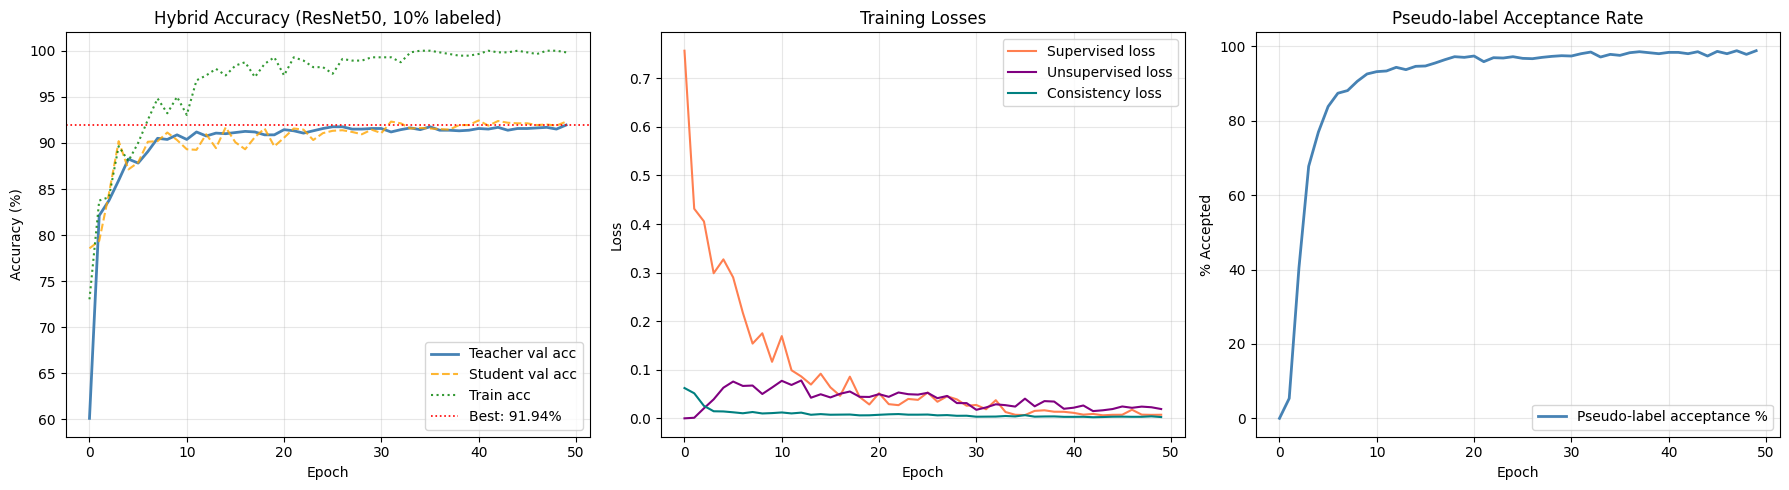

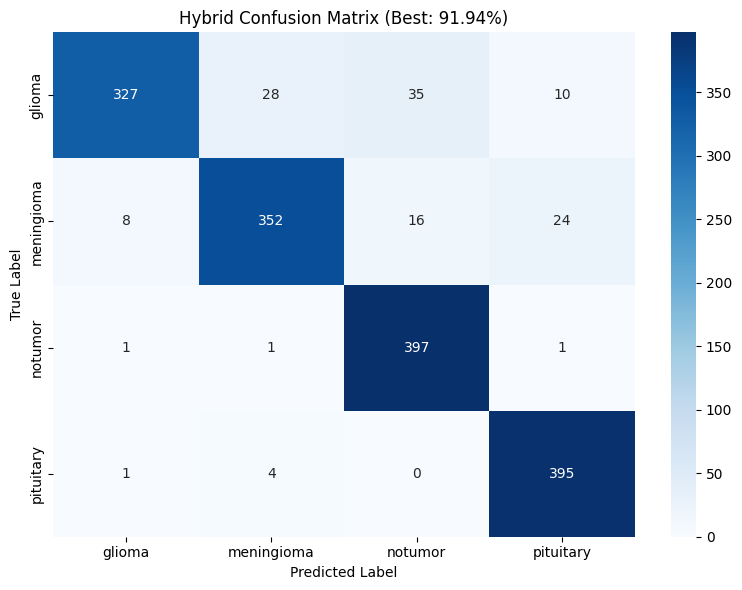


Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.82      0.89       400
  meningioma       0.91      0.88      0.90       400
     notumor       0.89      0.99      0.94       400
   pituitary       0.92      0.99      0.95       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# accuracy
axes[0].plot(history["val_teacher"], label="Teacher val acc", linewidth=2, color="steelblue")
axes[0].plot(history["val_student"], label="Student val acc", linewidth=1.5,
             linestyle="--", color="orange", alpha=0.8)
axes[0].plot(history["train_acc"],   label="Train acc",       linewidth=1.5,
             linestyle=":",  color="green",  alpha=0.8)
axes[0].axhline(y=best_acc, color="red", linestyle=":", linewidth=1.2,
                label=f"Best: {best_acc:.2f}%")
axes[0].set_title("Hybrid Accuracy (ResNet50, 10% labeled)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# losses
axes[1].plot(history["sup_loss"],   label="Supervised loss",   color="coral")
axes[1].plot(history["unsup_loss"], label="Unsupervised loss", color="purple")
axes[1].plot(history["cons_loss"],  label="Consistency loss",  color="teal")
axes[1].set_title("Training Losses")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

# mask ratio
axes[2].plot(history["mask_ratio"], label="Pseudo-label acceptance %",
             color="steelblue", linewidth=2)
axes[2].set_title("Pseudo-label Acceptance Rate")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("% Accepted")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("hybrid_results.png", dpi=150)
plt.show()

# confusion matrix
teacher.load_state_dict(torch.load("best_hybrid_teacher.pth"))
teacher.eval()
all_preds = []; all_labels = []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = teacher(imgs).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"Hybrid Confusion Matrix (Best: {best_acc:.2f}%)")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("hybrid_confusion_matrix.png", dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))